In [94]:
#logs to csvs of sweeps
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd #data stuff idk
import re #regex
import csv



def convert_to_csv(log_in_question, where_to_write_csvs, boot_delimeter, csvidx):
    pattern = r'(\d+) (-?\d+.\d+) (-?\d+.\d+) (-?\d+.\d+) (-?\d+)'

    logfile = open(log_in_question, 'r', encoding='ISO-8859-1')
    log = logfile.read()

    sweeps = log.split(boot_delimeter)
    
    parsed_sweeps = [""] * len(sweeps)
    
    for idx, sweep in enumerate(sweeps):
        for line in sweep.split('\n'):
            m = re.search(pattern, line)
            if m:
                toadd = m.group(0) + '\n'
                parsed_sweeps[idx] += toadd.replace(" ", ", ")
    
    for n in range(len(parsed_sweeps)):
        #write to files
        towrite = open(where_to_write_csvs+"_s"+str(n)+".csv", 'w')
        for idx, m in enumerate(list(csvidx.keys())):
            toappend = m
            if(idx != len(list(csvidx.keys())) - 1):
                toappend += ","
            towrite.write(toappend)
        towrite.write("\n")
        
        towrite.write(parsed_sweeps[n])



In [95]:
# change this based on what the firmware is spitting out
csvidx = {
    "uptime": 0,
    "voltage_mV": 1,
    "current_uA": 2,
    "power_mW": 3,
    "iadj_uV": 4
}

convert_to_csv("./logs/10p_1.log", "./raw/10p", "Oresat MCXN947 Solar Board App", csvidx)
convert_to_csv("./logs/20p_1.log", "./raw/20p", "Oresat MCXN947 Solar Board App", csvidx)
convert_to_csv("./logs/30p_1.log", "./raw/30p", "Oresat MCXN947 Solar Board App", csvidx)
convert_to_csv("./logs/40p_1.log", "./raw/40p", "Oresat MCXN947 Solar Board App", csvidx)
convert_to_csv("./logs/50p_1.log", "./raw/50p", "Oresat MCXN947 Solar Board App", csvidx)
convert_to_csv("./logs/60p_1.log", "./raw/60p", "Oresat MCXN947 Solar Board App", csvidx)
convert_to_csv("./logs/70p_1.log", "./raw/70p", "Oresat MCXN947 Solar Board App", csvidx)
# convert_to_csv("./logs/80p_1.log", "./raw/80p", "Oresat MCXN947 Solar Board App", csvidx)
convert_to_csv("./logs/90p_1.log", "./raw/90p", "Oresat MCXN947 Solar Board App", csvidx)
convert_to_csv("./logs/100p_1.log", "./raw/100p", "Oresat MCXN947 Solar Board App", csvidx)



In [90]:
#pick the good ones right mate
def slice(toslice, towrite):
    incsv = pd.read_csv(toslice)
    o = open(towrite, 'w')
    o.write("current_uA,voltage_mV,power_mW\n")
    for idx in range(len(incsv)):
        o.write(str(incsv.iloc[idx].iloc[csvidx["current_uA"]]) + ",")
        o.write(str(incsv.iloc[idx].iloc[csvidx["voltage_mV"]]) + ",")
        o.write(str(incsv.iloc[idx].iloc[csvidx["power_mW"]]) + "\n")
        
    # print(csv.iloc[2])


slice("raw/10p_s3.csv", "processed/10p.csv")
slice("raw/20p_s2.csv", "processed/20p.csv")
slice("raw/30p_s3.csv", "processed/30p.csv")
slice("raw/40p_s3.csv", "processed/40p.csv")
slice("raw/50p_s3.csv", "processed/50p.csv")
slice("raw/60p_s3.csv", "processed/60p.csv")
slice("raw/70p_s3.csv", "processed/70p.csv")
# slice("raw/80p_s3.csv", "processed/80p.csv")
slice("raw/90p_s3.csv", "processed/90p.csv")
slice("raw/100p_s0.csv", "processed/100p.csv")






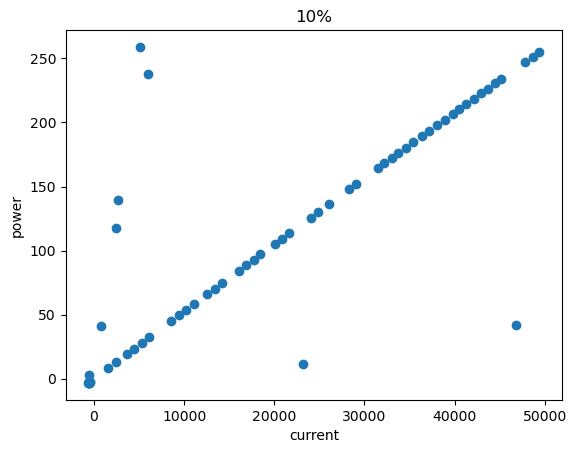

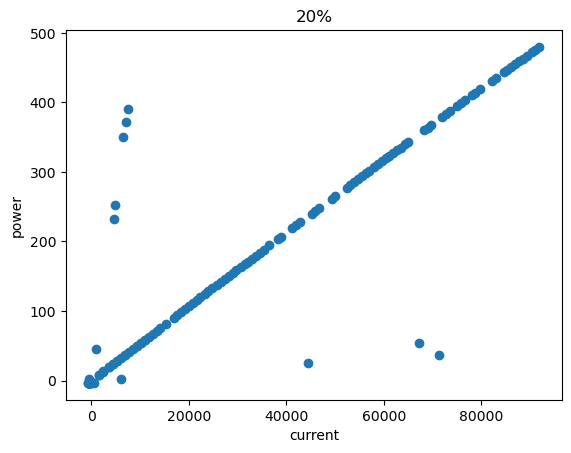

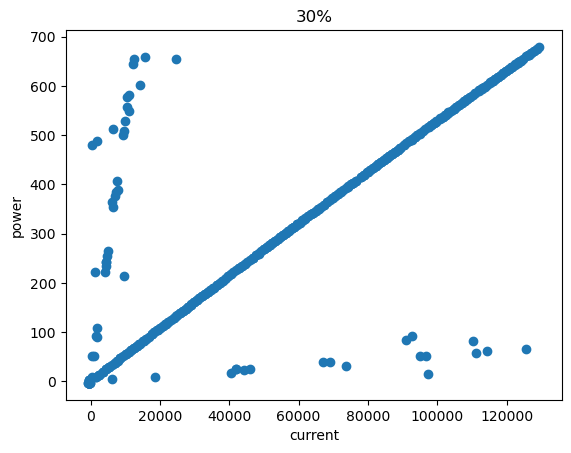

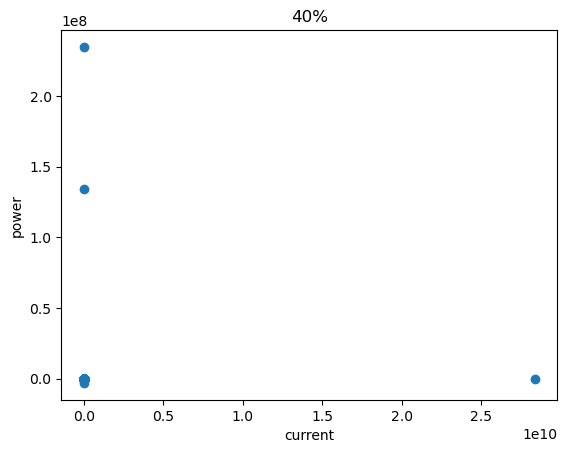

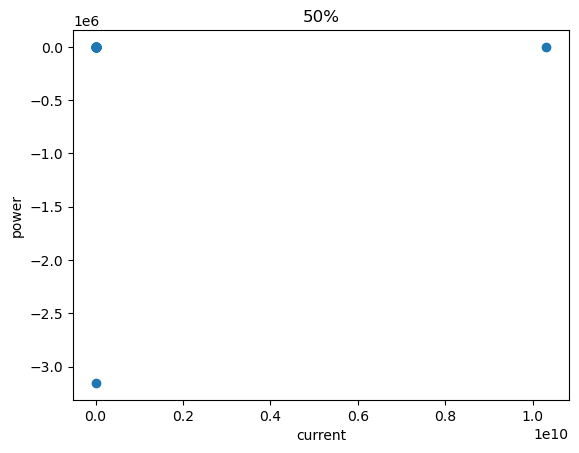

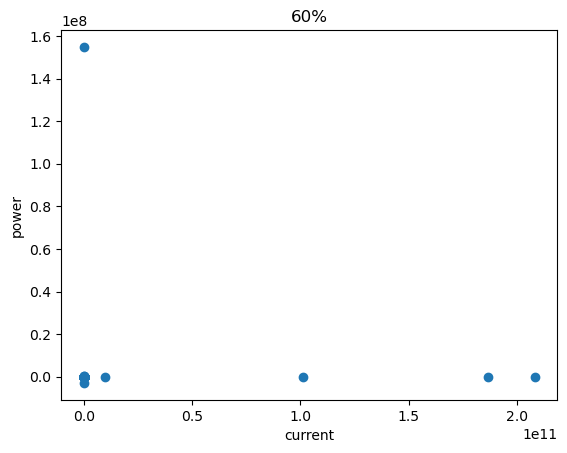

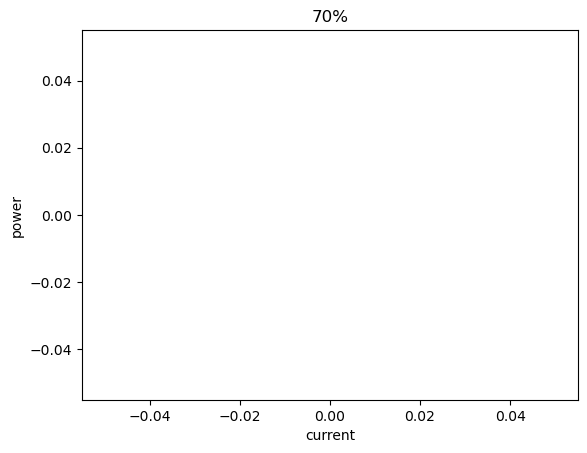

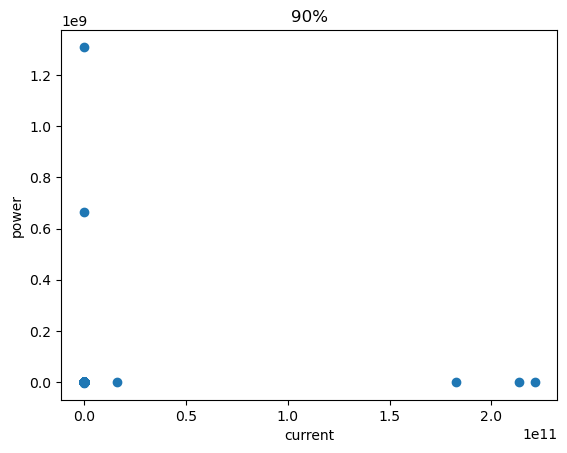

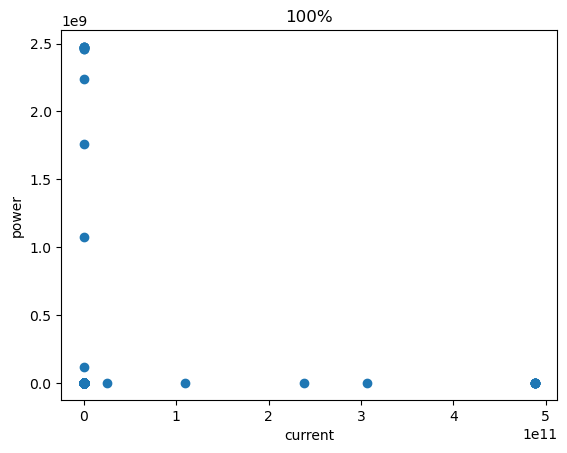

In [107]:
p10 = pd.read_csv("processed/10p.csv")
p20 = pd.read_csv("processed/20p.csv")
p30 = pd.read_csv("processed/30p.csv")
p40 = pd.read_csv("processed/40p.csv")
p50 = pd.read_csv("processed/50p.csv")
p60 = pd.read_csv("processed/60p.csv")
p70 = pd.read_csv("processed/70p.csv")
# p80 = pd.read_csv("processed/80p.csv")
p90 = pd.read_csv("processed/90p.csv")
p100 = pd.read_csv("processed/100p.csv")

def plotfunc(csv, title):
    plt.scatter(csv['current_uA'].tolist(), csv['power_mW'].tolist())
    plt.title(title)
    plt.xlabel("current")
    plt.ylabel("power")
    plt.show()
    
plotfunc(p10, "10%")
plotfunc(p20, "20%")
plotfunc(p30, "30%")
plotfunc(p40, "40%")
plotfunc(p50, "50%")
plotfunc(p60, "60%")
plotfunc(p70, "70%")
# plotfunc(p80, "80%")
plotfunc(p90, "90%")
plotfunc(p100, "100%")




